# Teaching a language model to play tic-tac-toe with PPO

This notebook trains **GPT-2 (124M)** to play tic-tac-toe using reinforcement learning,
and measures exactly how much it improved.

The run is organised so that every claim at the end is backed by a number produced earlier:

| part | what happens |
|---|---|
| **1. Data preparation** | build the game, the text format, and the answer tokens |
| **2. Load the model** | wrap GPT-2 into a policy, save an untrained copy |
| **3. Test the untrained model** | play `N_GAMES` games, score them → *baseline* |
| **4. Train with PPO** | play games, reward outcomes, update weights |
| **5. Save the trained model** | write a checkpoint to disk |
| **6. Test the trained model** | replay the *same* tests → *result* |
| **7. Compare** | before vs after, side by side, with reference points |
| **8. Play against it** | interactive game + move-by-move inspection |

**Runtime:** ~70 minutes on a Colab GPU (T4 or better). Set `Runtime > Change runtime type > GPU`.
On CPU, reduce `ITERS` and `GAMES_PER_ITER` as noted in Part 4.

In [ ]:
%pip install -q torch transformers

---
# Part 1 — Data preparation

## 1.0 What "data preparation" means for RL

There is **no dataset of correct moves** in this notebook. Nobody tells the model the right answer.
Instead we build a machine that turns *games the model just played* into training examples:

```
play a game  →  record each decision  →  game ends: +1 win / 0 draw / -1 loss
             →  spread that score back over the decisions  →  train  →  discard  →  repeat
```

So Part 1 builds four things: the **game rules**, an **exact solver** (used only for grading, never
for training), the **text format** the model reads, and the **nine tokens** that count as answers.

## 1.1 The game engine

A board is a tuple of 9 integers, read left-to-right, top-to-bottom:

```
cell numbers        example board        stored as
 0 1 2               X . .
 3 4 5               . O .               (1,0,0, 0,2,0, 0,0,0)
 6 7 8               . . .
```

`0` = empty, `1` = X, `2` = O. Tuples are used because they are immutable and hashable, which lets
us cache solver results and enumerate states without accidental mutation bugs.

In [ ]:
EMPTY, X, O = 0, 1, 2
SYM = {EMPTY: ".", X: "X", O: "O"}
LINES = ((0,1,2),(3,4,5),(6,7,8),(0,3,6),(1,4,7),(2,5,8),(0,4,8),(2,4,6))
EMPTY_BOARD = (EMPTY,) * 9


def other(mark):
    return O if mark == X else X


def winner(board):
    """Returns X, O, or EMPTY if nobody has three in a row."""
    for i, j, k in LINES:
        if board[i] != EMPTY and board[i] == board[j] == board[k]:
            return board[i]
    return EMPTY


def legal_moves(board):
    return [i for i in range(9) if board[i] == EMPTY]


def is_terminal(board):
    return winner(board) != EMPTY or EMPTY not in board


def place(board, cell, mark):
    assert board[cell] == EMPTY, f"illegal move {cell} on {board}"
    b = list(board)
    b[cell] = mark
    return tuple(b)


def render(board):
    return "\n".join(" ".join(SYM[board[r * 3 + c]] for c in range(3)) for r in range(3))


def outcome_reward(board, mark):
    """The only reward signal in this notebook: +1 win, 0 draw, -1 loss, from `mark`'s view."""
    w = winner(board)
    if w == EMPTY:
        return 0.0
    return 1.0 if w == mark else -1.0


print(render(place(place(EMPTY_BOARD, 0, X), 4, O)))

X . .
. O .
. . .


## 1.2 The exact solver (minimax) — for grading and for practice partners

Tic-tac-toe is small enough to solve perfectly. `_minimax` searches the whole game tree and returns
the true value of a position, so we always know the correct answer.

**This is never used as a training target.** It is used in exactly two places:

1. As the strong practice partner during training and testing.
2. As the grader — to say whether a move the model chose was correct.

`move_scores` gives the value of every legal move; `optimal_moves` gives the cells that achieve the
best outcome still available. Scores are multiplied by `0.99` per ply so quick wins outrank slow ones.

In [ ]:
import math
from functools import lru_cache


@lru_cache(maxsize=None)
def _minimax(board, to_move):
    """(value for X, best move). Memoised, so the whole tree is solved once."""
    w = winner(board)
    if w != EMPTY:
        return (1.0 if w == X else -1.0), -1
    moves = legal_moves(board)
    if not moves:
        return 0.0, -1
    best_score, best_move = (-math.inf if to_move == X else math.inf), moves[0]
    for m in moves:
        s, _ = _minimax(place(board, m, to_move), other(to_move))
        s *= 0.99
        if (to_move == X and s > best_score) or (to_move == O and s < best_score):
            best_score, best_move = s, m
    return best_score, best_move


def move_scores(board, mark):
    """Value of each legal move, always expressed from X's point of view."""
    return {c: _minimax(place(board, c, mark), other(mark))[0] * 0.99
            for c in legal_moves(board)}


def optimal_moves(board, mark, tol=1e-9):
    s = move_scores(board, mark)
    best = max(s.values()) if mark == X else min(s.values())
    return [c for c, v in s.items() if abs(v - best) <= tol]


def position_is_lost(board, mark):
    s = move_scores(board, mark)
    best = max(s.values()) if mark == X else min(s.values())
    return (best < -0.5) if mark == X else (best > 0.5)


def is_blunder(board, mark, move):
    """True if `move` loses a position that was NOT already lost. The sharpest error measure."""
    if position_is_lost(board, mark):
        return False
    v = move_scores(board, mark)[move]
    return (v < -0.5) if mark == X else (v > 0.5)


# X to move, O threatens the middle row 3-4-5: cell 5 is the only non-losing move
_b = EMPTY_BOARD
for _c, _m in [(0, X), (3, O), (8, X), (4, O)]:
    _b = place(_b, _c, _m)
print(render(_b))
print("scores :", {k: round(v, 2) for k, v in move_scores(_b, X).items()})
print("optimal:", optimal_moves(_b, X))

X . .
O O .
. . X
scores : {1: -0.98, 2: -0.98, 5: 0.0, 6: -0.98, 7: -0.98}
optimal: [5]


## 1.3 Practice partners (opponents)

Two opponents, and a mix of the two:

- **`random_opponent`** — picks any empty cell. Easy, and essential early: the model wins often
  enough to get useful feedback.
- **`minimax_opponent`** — plays perfectly. Never loses.
- **`mixed_opponent(p)`** — random with probability `p`, otherwise perfect.

`eps` adds a small amount of randomness even to the "perfect" opponent. This matters for testing:
a fully deterministic opponent against a deterministic model replays the *same game every time*,
so 200 test games would contain only 1 distinct game. `eps=0.15` prevents that.

In [ ]:
import random


def random_opponent(board, mark):
    return random.choice(legal_moves(board))


def minimax_opponent(board, mark, eps=0.0):
    if eps and random.random() < eps:
        return random.choice(legal_moves(board))
    return _minimax(board, mark)[1]


def mixed_opponent(random_prob, eps=0.0):
    def move(board, mark):
        if random.random() < random_prob:
            return random_opponent(board, mark)
        return minimax_opponent(board, mark, eps=eps)
    return move


def eps_minimax(eps=0.15):
    return lambda b, m: minimax_opponent(b, m, eps=eps)

## 1.4 Turning a board into text

GPT-2 only understands text, so the board is described in words. Two details are deliberate:

1. **The prompt stops mid-sentence, right after `Best cell:`.** A language model's job is to predict
   what comes next — so by cutting off there, the next token it wants to produce *is the move*.
2. **Legal cells are listed explicitly.** The model can attend to that line instead of having to
   infer emptiness from the grid.

In [ ]:
PROMPT_VERSION = "v1"   # bump this if the template changes; old checkpoints become invalid


def build_prompt(board, mark):
    moves = " ".join(str(m) for m in legal_moves(board))
    return (
        "Tic-tac-toe. Cells are numbered 0-8, left to right, top to bottom.\n"
        f"You are {SYM[mark]}. Opponent is {SYM[other(mark)]}.\n"
        "Board:\n"
        f"{render(board)}\n"
        f"Legal cells: {moves}\n"
        "Best cell:"
    )


def legal_mask(board):
    """Boolean array of length 9: True where a move is allowed."""
    import numpy as np
    return np.array([board[i] == EMPTY for i in range(9)], dtype=bool)


print(build_prompt(_b, X))

Tic-tac-toe. Cells are numbered 0-8, left to right, top to bottom.
You are X. Opponent is O.
Board:
X . .
O O .
. . X
Legal cells: 1 2 5 6 7
Best cell:


## 1.5 How big is the problem? (enumerating every position)

Tic-tac-toe is small enough to enumerate completely. Knowing these numbers lets us grade the model
on **every position that exists**, with no sampling noise at all — a luxury you never get on a real task.

`all_decision_states()` walks the game tree from the empty board and returns every
`(board, to_move)` pair where a move is still required.

In [ ]:
def all_decision_states():
    seen = set()

    def walk(board, to_move):
        if (board, to_move) in seen:
            return
        seen.add((board, to_move))
        if is_terminal(board):
            return
        for c in legal_moves(board):
            walk(place(board, c, to_move), other(to_move))

    walk(EMPTY_BOARD, X)
    return sorted(s for s in seen if not is_terminal(s[0]))


DECISION_STATES = all_decision_states()
_forced = sum(1 for b, m in DECISION_STATES if len(optimal_moves(b, m)) == 1)
_chance_top1 = sum(len(optimal_moves(b, m)) / len(legal_moves(b)) for b, m in DECISION_STATES) / len(DECISION_STATES)
_chance_blunder = sum(
    0.0 if position_is_lost(b, m) else
    sum(is_blunder(b, m, c) for c in legal_moves(b)) / len(legal_moves(b))
    for b, m in DECISION_STATES) / len(DECISION_STATES)

print(f"positions where a move is required : {len(DECISION_STATES)}")
print(f"  ... with exactly one correct move: {_forced} ({_forced/len(DECISION_STATES):.1%})")
print(f"random guessing would score        : top-1 {_chance_top1:.3f}, blunder {_chance_blunder:.3f}")

positions where a move is required : 4520
  ... with exactly one correct move: 3142 (69.5%)
random guessing would score        : top-1 0.494, blunder 0.340


### Reference points: what a perfect and a random player actually score

Before measuring the model, we compute *exactly* — by full expansion of the game tree, no simulation —
how a perfect player and a random player fare against a random opponent. Without these, a number like
"79% wins" is meaningless.

In [ ]:
@lru_cache(maxsize=None)
def _exact(board, to_move, agent_mark, agent):
    if is_terminal(board):
        w = winner(board)
        if w == EMPTY:
            return (0.0, 1.0, 0.0)
        return (1.0, 0.0, 0.0) if w == agent_mark else (0.0, 0.0, 1.0)
    moves = legal_moves(board)
    if to_move == agent_mark and agent == "perfect":
        moves = [_minimax(board, to_move)[1]]
    res = [_exact(place(board, m, to_move), other(to_move), agent_mark, agent) for m in moves]
    return tuple(sum(r[i] for r in res) / len(res) for i in range(3))


def exact_reference(agent):
    """(win, draw, loss) vs a uniform-random opponent, averaged over playing X and O."""
    a = _exact(EMPTY_BOARD, X, X, agent)
    b = _exact(EMPTY_BOARD, X, O, agent)
    return tuple((a[i] + b[i]) / 2 for i in range(3))


REF_RANDOM = exact_reference("random")
REF_PERFECT = exact_reference("perfect")
print(f"random player vs random opponent : win {REF_RANDOM[0]:.3f}  draw {REF_RANDOM[1]:.3f}  loss {REF_RANDOM[2]:.3f}")
print(f"perfect player vs random opponent: win {REF_PERFECT[0]:.3f}  draw {REF_PERFECT[1]:.3f}  loss {REF_PERFECT[2]:.3f}")

random player vs random opponent : win 0.437  draw 0.127  loss 0.437
perfect player vs random opponent: win 0.901  draw 0.099  loss 0.000


---
# Part 2 — Loading the model

## 2.0 Configuration

Every knob in one place. The three marked **[fix]** address bugs found in an earlier run of this
experiment — see the notes beside each.

In [ ]:
import time, json, os
from dataclasses import dataclass, asdict
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 0
torch.manual_seed(SEED); random.seed(SEED); np.random.seed(SEED)


@dataclass
class Config:
    model_name: str = "gpt2"              # 124M
    # --- training
    iters: int = 150
    games_per_iter: int = 128             # [fix] was 64 -> noisy advantages
    ppo_epochs: int = 4
    minibatch: int = 64
    lr: float = 3e-5
    value_lr: float = 3e-4
    clip: float = 0.2
    vf_coef: float = 0.5
    ent_coef: float = 0.02
    gamma: float = 0.98
    max_grad_norm: float = 1.0            # policy only
    value_max_grad_norm: float = 10.0     # [fix] critic needs its own budget
    critic_warmup: int = 10               # [fix] fit the critic before moving the policy
    random_open_prob: float = 0.5         # start some games from a random opening
    # --- opponent curriculum
    opp_random_start: float = 1.0
    opp_random_end: float = 0.2
    opp_anneal_frac: float = 0.6
    opp_eps: float = 0.15
    # --- evaluation
    n_games: int = 400                    # N in "test with N games"
    eval_every: int = 25
    freeze_below: int = 0                 # freeze the first N blocks (raise this on CPU)

cfg = Config()
N_GAMES = cfg.n_games
print("device:", DEVICE, "| N_GAMES:", N_GAMES)

device: cuda | N_GAMES: 400


## 2.1 The nine answer tokens

The model can emit ~50,000 different tokens. We only ever look at nine of them: the digits `0`-`8`.

Tokenizers differ between models, so we don't hardcode ids — we *resolve* them, trying `" 0"` first
(with a leading space, which is how GPT-2 usually represents a digit mid-sentence) and falling back
to `"0"`. The chosen scheme is recorded so that testing later uses exactly the same tokens.

In [ ]:
tok = AutoTokenizer.from_pretrained(cfg.model_name)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token
tok.padding_side = "left"      # keeps the decision position at index -1 for every prompt


def resolve_action_tokens(tok):
    for scheme in (" {}", "{}"):
        ids = [tok.encode(scheme.format(i), add_special_tokens=False) for i in range(9)]
        if all(len(t) == 1 for t in ids):
            return scheme, [t[0] for t in ids]
    raise RuntimeError("no single-token scheme found for digits 0-8")


ACTION_SCHEME, ACTION_IDS = resolve_action_tokens(tok)
ACTION_TOKENS = torch.tensor(ACTION_IDS)
print("scheme:", repr(ACTION_SCHEME), "| token ids:", ACTION_IDS)
print("decoded:", [tok.decode([i]) for i in ACTION_IDS])


def encode(prompts, device=DEVICE):
    enc = tok(prompts, return_tensors="pt", padding=True)
    ids = enc["input_ids"].to(device)
    mask = enc["attention_mask"].to(device)
    # GPT-2 does NOT derive position ids from the mask; with left padding we must build them,
    # otherwise a padded prompt believes it starts partway through a document.
    pos = (mask.long().cumsum(-1) - 1).masked_fill(mask == 0, 0)
    return ids, mask, pos

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

scheme: ' {}' | token ids: [657, 352, 362, 513, 604, 642, 718, 767, 807]
decoded: [' 0', ' 1', ' 2', ' 3', ' 4', ' 5', ' 6', ' 7', ' 8']


## 2.2 The policy

Two heads on one GPT-2 body:

**Policy head** — the model's existing output layer, but we read only the 9 rows belonging to our
answer tokens instead of all 50,257. Then occupied cells are set to `-inf`, so their probability is
*exactly* zero. **The model cannot produce an illegal move**, which means all of training is spent
on move quality rather than on learning the output format.

**Value head** — a small new network that predicts "how well is this position going to go for me?"
PPO needs it to judge whether an outcome was better or worse than expected. It starts out random,
which is why it gets a higher learning rate and a warm-up phase.

In [ ]:

class Policy(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.lm = AutoModelForCausalLM.from_pretrained(cfg.model_name)
        self.lm.config.pad_token_id = tok.pad_token_id
        n_embd = self.lm.config.hidden_size
        self.value_head = nn.Sequential(nn.Linear(n_embd, n_embd), nn.Tanh(), nn.Linear(n_embd, 1))
        nn.init.normal_(self.value_head[-1].weight, std=0.01)
        nn.init.zeros_(self.value_head[-1].bias)
        self.register_buffer("action_tokens", ACTION_TOKENS.clone(), persistent=False)
        for i, block in enumerate(self.lm.base_model.h if hasattr(self.lm.base_model, "h")
                                  else self.lm.base_model.layers):
            if i < cfg.freeze_below:
                for p in block.parameters():
                    p.requires_grad_(False)

    def forward(self, ids, attn, pos, legal):
        h = self.lm.base_model(input_ids=ids, attention_mask=attn,
                               position_ids=pos).last_hidden_state[:, -1]
        logits = h @ self.lm.get_output_embeddings().weight[self.action_tokens].t()
        logits = logits.masked_fill(~legal, torch.finfo(logits.dtype).min)
        return logits, self.value_head(h).squeeze(-1)


def make_optimizer(policy, cfg):
    backbone = [p for n, p in policy.named_parameters()
                if p.requires_grad and not n.startswith("value_head")]
    return torch.optim.AdamW([
        {"params": backbone, "lr": cfg.lr},
        {"params": list(policy.value_head.parameters()), "lr": cfg.value_lr},
    ], weight_decay=0.0), backbone, list(policy.value_head.parameters())


policy = Policy(cfg).to(DEVICE)
optim, POL_PARAMS, VAL_PARAMS = make_optimizer(policy, cfg)
n_all = sum(p.numel() for p in policy.parameters())
n_train = sum(p.numel() for p in policy.parameters() if p.requires_grad)
print(f"parameters: {n_all/1e6:.2f}M total, {n_train/1e6:.2f}M trainable "
      f"({policy.value_head[0].in_features}-dim hidden)")

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

parameters: 125.03M total, 125.03M trainable (768-dim hidden)


## 2.3 Save the untrained model

Before touching a single weight, the untrained policy is written to disk. This is what "before RL"
means later — not a re-initialised model, but *exactly* the network we are about to train.

In [ ]:
os.makedirs("checkpoints", exist_ok=True)


def save_checkpoint(policy, path, **meta):
    os.makedirs(path, exist_ok=True)
    torch.save(policy.state_dict(), f"{path}/model.pt")
    manifest = dict(base_model=cfg.model_name, prompt_version=PROMPT_VERSION,
                    action_scheme=ACTION_SCHEME, seed=SEED, config=asdict(cfg), **meta)
    with open(f"{path}/manifest.json", "w") as f:
        json.dump(manifest, f, indent=2, default=str)
    return path


def load_checkpoint(path, device=DEVICE):
    with open(f"{path}/manifest.json") as f:
        man = json.load(f)
    assert man["prompt_version"] == PROMPT_VERSION, "prompt changed - checkpoint is incomparable"
    assert man["action_scheme"] == ACTION_SCHEME, "action token scheme changed"
    p = Policy(cfg).to(device)
    p.load_state_dict(torch.load(f"{path}/model.pt", map_location=device))
    p.eval()
    return p, man


save_checkpoint(policy, "checkpoints/00_untrained", stage="untrained", games_seen=0)
print("saved -> checkpoints/00_untrained")

saved -> checkpoints/00_untrained


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

# Take a look at what's there so the path in the next cell is correct
import os
DRIVE_ROOT = "/content/drive/MyDrive"
os.listdir(DRIVE_ROOT)[:20]   # find the folder or file you saved to

Mounted at /content/drive


['Getting started.pdf',
 'monika',
 'Copy of KPMG_VI_New_raw_data_update_final.gsheet',
 'KPMG_VI_New_raw_data_update_final.gsheet',
 'AI Hackathon.rtf.gdoc',
 'Untitled document (33).gdoc',
 'IMG_20210811_094152.jpg',
 '20JG1A4231, physics assignment.pdf',
 'python projects.pdf',
 'Colab Notebooks',
 'IMG_20210913_224755.jpg',
 'Screenshot_2021-09-13-22-52-32-20_e2d5b3f32b79de1d45acd1fad96fbb0f.jpg',
 'IMG_20210918_235016.jpg',
 'IMG_20210918_235001.jpg',
 'IMG_20210918_234911.jpg',
 'IMG_20210918_234742.jpg',
 'IMG_20210918_234659.jpg',
 'IMG_20210918_234621.jpg',
 'IMG_20210918_234314.jpg',
 'IMG_20210918_233955.jpg']

In [ ]:
import os, json, torch

# EDIT THIS to match where your file is
CKPT_PATH = "/content/drive/MyDrive/gpt2_ttt_ppo.pt"
# examples of what also works:
#   CKPT_PATH = "/content/drive/MyDrive/my_stuff/gpt2_ttt.pt"      # bare .pt file
#   CKPT_PATH = "/content/drive/MyDrive/tictactoe_rl/01_ppo"       # a folder


def resolve_checkpoint_path(user_path):
    p = os.path.expanduser(user_path.rstrip("/"))
    if os.path.isdir(p):
        d = p
    elif os.path.isfile(p) and p.endswith(".pt"):
        d = os.path.dirname(p)
    else:
        raise FileNotFoundError(
            f"Nothing at {p!r}. Drive lives at /content/drive/MyDrive/... — "
            "did you mount Drive in the previous cell?"
        )
    model_path = os.path.join(d, "model.pt")
    manifest_path = os.path.join(d, "manifest.json")
    if not os.path.isfile(model_path):
        pt_files = [f for f in os.listdir(d) if f.endswith(".pt")]
        if len(pt_files) == 1:
            model_path = os.path.join(d, pt_files[0])
        elif len(pt_files) > 1:
            raise FileNotFoundError(f"{d} has multiple .pt files: {pt_files} — point at one directly.")
        else:
            raise FileNotFoundError(f"No .pt file in {d}")
    manifest = json.load(open(manifest_path)) if os.path.isfile(manifest_path) else None
    return model_path, manifest


model_path, manifest = resolve_checkpoint_path(CKPT_PATH)
print(f"Loading weights from: {model_path}")
if manifest:
    print(f"Manifest says: base_model={manifest.get('base_model')} "
          f"prompt_version={manifest.get('prompt_version')} "
          f"action_scheme={manifest.get('action_scheme')!r} "
          f"games_seen={manifest.get('games_seen')}")
    # sanity: warn if the prompt or action scheme changed since training
    if manifest.get("prompt_version") and manifest["prompt_version"] != PROMPT_VERSION:
        print(f"⚠️  prompt_version mismatch: checkpoint={manifest['prompt_version']} notebook={PROMPT_VERSION}")
        print("    The model was trained on a different prompt format — outputs will be nonsense.")
    if manifest.get("action_scheme") and manifest["action_scheme"] != ACTION_SCHEME:
        print(f"⚠️  action_scheme mismatch: checkpoint={manifest['action_scheme']!r} "
              f"notebook={ACTION_SCHEME!r}")

# instantiate a fresh Policy on the current DEVICE, then load
policy = Policy(cfg).to(DEVICE)
state_dict = torch.load(model_path, map_location=DEVICE)
# some save conventions store the state_dict directly, others wrap it in a dict
if isinstance(state_dict, dict) and "model" in state_dict and not any(
        k.startswith("lm.") or k.startswith("value_head.") for k in state_dict):
    state_dict = state_dict["model"]

missing, unexpected = policy.load_state_dict(state_dict, strict=False)
if missing:    print(f"⚠️  missing keys: {missing[:5]}{'...' if len(missing)>5 else ''}")
if unexpected: print(f"⚠️  unexpected keys: {unexpected[:5]}{'...' if len(unexpected)>5 else ''}")
policy.eval()

# quick sanity check: run one prompt and confirm the output looks like a probability distribution
with torch.no_grad():
    ids, attn, pos = encode([build_prompt(EMPTY_BOARD, X)])
    legal = torch.from_numpy(legal_mask(EMPTY_BOARD)[None]).to(DEVICE)
    logits, value = policy(ids, attn, pos, legal)
    probs = logits.softmax(-1)[0].float().cpu().numpy()
print(f"\nSanity check on empty board, X to move:")
print(f"  value head estimate: {float(value):+.3f}")
print(f"  probability per cell: {[f'{p:.3f}' for p in probs]}")
print(f"  sums to: {probs.sum():.4f}  (should be 1.0000)")
print(f"  argmax cell: {int(probs.argmax())}")
print("\n✓ model loaded and callable. Run the Gradio cell next.")

Loading weights from: /content/drive/MyDrive/gpt2_ttt_ppo.pt


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]


Sanity check on empty board, X to move:
  value head estimate: +0.481
  probability per cell: ['0.997', '0.000', '0.003', '0.000', '0.000', '0.000', '0.000', '0.000', '0.000']
  sums to: 1.0000  (should be 1.0000)
  argmax cell: 0

✓ model loaded and callable. Run the Gradio cell next.


---
# Part 3 — Testing the model (before any training)

## 3.0 Two kinds of test

**Game-level** — play `N_GAMES` complete games and count wins, draws and losses. This is what people
intuitively want, but it saturates: an agent that can't defend still beats a random opponent most of
the time.

**Position-level** — show the model *every one of the 4,520 positions* and check whether its chosen
move is correct according to the solver. No sampling, no noise, and it pinpoints *which* skills are
missing. This is the more informative measurement.

Both are run identically before and after training.

## 3.1 The rollout engine

Games are played **in parallel batches**, not one at a time: all games waiting on the model are
collected, their prompts encoded together, and one forward pass produces every move. This is the
difference between minutes and hours.

For each of the model's own decisions we record the four things PPO needs later: the prompt, the
move, how confident the model was (`logp`), and what it expected (`value`).

In [ ]:
@torch.no_grad()
def act(policy, boards, marks, greedy=False):
    prompts = [build_prompt(b, m) for b, m in zip(boards, marks)]
    ids, attn, pos = encode(prompts)
    legal = torch.from_numpy(np.stack([legal_mask(b) for b in boards])).to(DEVICE)
    logits, value = policy(ids, attn, pos, legal)
    dist = torch.distributions.Categorical(logits=logits)
    action = logits.argmax(-1) if greedy else dist.sample()
    return prompts, action, dist.log_prob(action), value, legal


def _random_opening(rng, max_plies=2):
    board = EMPTY_BOARD
    for _ in range(rng.choice([1, 2]) if max_plies else 0):
        if is_terminal(board):
            break
        to_move = X if board.count(EMPTY) % 2 == 1 else O
        board = place(board, rng.choice(legal_moves(board)), to_move)
    return board


def play_batch(policy, n_games, opponent, greedy=False, collect=True, random_open=0.0, gamma=0.98):
    """Plays n_games in parallel. Agent is X in half of them, O in the other half."""
    rng = random
    boards = [_random_opening(rng) if rng.random() < random_open else EMPTY_BOARD
              for _ in range(n_games)]
    to_move = [X if b.count(EMPTY) % 2 == 1 else O for b in boards]
    agent_mark = [X if g % 2 == 0 else O for g in range(n_games)]
    steps = [[] for _ in range(n_games)]
    live = list(range(n_games))

    while live:
        for g in list(live):                      # let the opponent move until it's our turn
            while not is_terminal(boards[g]) and to_move[g] != agent_mark[g]:
                boards[g] = place(boards[g], opponent(boards[g], to_move[g]), to_move[g])
                to_move[g] = other(to_move[g])
            if is_terminal(boards[g]):
                live.remove(g)
        if not live:
            break

        prompts, actions, logps, values, legals = act(
            policy, [boards[g] for g in live], [agent_mark[g] for g in live], greedy=greedy)
        for i, g in enumerate(live):
            a = int(actions[i])
            if collect:
                steps[g].append(dict(prompt=prompts[i], action=a, logp=float(logps[i]),
                                     value=float(values[i]), legal=legals[i].cpu().numpy()))
            boards[g] = place(boards[g], a, agent_mark[g])
            to_move[g] = other(to_move[g])
        live = [g for g in live if not is_terminal(boards[g])]

    buffer, results = [], []
    for g in range(n_games):
        r = outcome_reward(boards[g], agent_mark[g])
        results.append(r)
        T = len(steps[g])
        for t, s in enumerate(steps[g]):          # discount the outcome back over our own moves
            s["ret"] = r * (gamma ** (T - 1 - t))
            buffer.append(s)
    return buffer, np.array(results)

## 3.2 Scoring: game-level and position-level

`play_and_score` returns raw counts (not just fractions) so confidence intervals can be computed.

`exhaustive_score` sweeps all 4,520 positions in batches and reports:

- **top-1** — fraction where the model's best move is a correct move *(random guessing: 0.494)*
- **blunder** — fraction where it throws away a position that was not already lost *(random: 0.340, lower is better)*
- **top-1 forced** — restricted to positions with exactly one right answer, the hardest subset

In [ ]:
def wilson(k, n, z=1.96):
    if n == 0:
        return (0.0, 0.0)
    p = k / n
    d = 1 + z * z / n
    c = p + z * z / (2 * n)
    h = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n))
    return ((c - h) / d, (c + h) / d)


def two_prop_z(k1, n1, k2, n2):
    pp = (k1 + k2) / (n1 + n2)
    se = math.sqrt(pp * (1 - pp) * (1 / n1 + 1 / n2))
    if se == 0:
        return 0.0, 1.0
    z = (k1 / n1 - k2 / n2) / se
    return z, math.erfc(abs(z) / math.sqrt(2))


@torch.no_grad()
def play_and_score(policy, n_games, opponent, greedy=True):
    was = policy.training
    policy.eval()
    _, res = play_batch(policy, n_games, opponent, greedy=greedy, collect=False)
    if was:
        policy.train()
    return dict(n=len(res), win=int((res > 0).sum()),
                draw=int((res == 0).sum()), loss=int((res < 0).sum()))


@torch.no_grad()
def exhaustive_score(policy, states=None, batch=256):
    """Grade the model on EVERY position in the game. No sampling noise."""
    states = states or DECISION_STATES
    was = policy.training
    policy.eval()
    hits = blunders = forced_n = forced_hits = 0
    per_ply = {}
    for i in range(0, len(states), batch):
        chunk = states[i:i + batch]
        ids, attn, pos = encode([build_prompt(b, m) for b, m in chunk])
        legal = torch.from_numpy(np.stack([legal_mask(b) for b, _ in chunk])).to(DEVICE)
        logits, _ = policy(ids, attn, pos, legal)
        for (b, m), a in zip(chunk, logits.argmax(-1).tolist()):
            opt = optimal_moves(b, m)
            ok = a in opt
            hits += ok
            blunders += is_blunder(b, m, a)
            if len(opt) == 1:
                forced_n += 1
                forced_hits += ok
            ply = 9 - b.count(EMPTY)
            d = per_ply.setdefault(ply, [0, 0])
            d[0] += ok; d[1] += 1
    if was:
        policy.train()
    n = len(states)
    return dict(top1=hits / n, blunder=blunders / n, top1_forced=forced_hits / max(1, forced_n),
                n=n, per_ply={k: v[0] / v[1] for k, v in sorted(per_ply.items())})

## 3.3 BASELINE RESULTS — the untrained model

`N_GAMES` games against a random opponent, `N_GAMES` against a near-perfect opponent, plus the
exhaustive position sweep. These numbers are the "before" column of the final comparison.

In [ ]:
RESULTS = {}


def full_evaluation(policy, label):
    t0 = time.time()
    out = dict(label=label,
               vs_random=play_and_score(policy, N_GAMES, random_opponent),
               vs_strong=play_and_score(policy, N_GAMES, eps_minimax(cfg.opp_eps)),
               positions=exhaustive_score(policy))
    r = out["vs_random"]; s = out["vs_strong"]; p = out["positions"]
    print(f"===== {label} =====")
    print(f"vs RANDOM opponent   (n={r['n']}): win {r['win']/r['n']:.3f}  "
          f"draw {r['draw']/r['n']:.3f}  loss {r['loss']/r['n']:.3f}")
    print(f"vs STRONG opponent   (n={s['n']}): win {s['win']/s['n']:.3f}  "
          f"draw {s['draw']/s['n']:.3f}  loss {s['loss']/s['n']:.3f}")
    print(f"all {p['n']} positions      : top-1 {p['top1']:.3f} (chance {_chance_top1:.3f})  "
          f"blunder {p['blunder']:.3f} (chance {_chance_blunder:.3f})  "
          f"top-1 forced {p['top1_forced']:.3f}")
    print(f"({time.time()-t0:.0f}s)")
    return out


RESULTS["before"] = full_evaluation(policy, "BEFORE TRAINING (untrained GPT-2)")

===== BEFORE TRAINING (untrained GPT-2) =====
vs RANDOM opponent   (n=400): win 0.775  draw 0.140  loss 0.085
vs STRONG opponent   (n=400): win 0.205  draw 0.787  loss 0.007
all 4520 positions      : top-1 0.632 (chance 0.494)  blunder 0.223 (chance 0.340)  top-1 forced 0.513
(25s)


In [ ]:
# ============================================================
#  Load the trained model from Google Drive
# ============================================================
import os, json, torch

# EDIT THIS to match where your file is
CKPT_PATH = "/content/drive/MyDrive/gpt2_ttt_ppo.pt"
# examples of what also works:
#   CKPT_PATH = "/content/drive/MyDrive/my_stuff/gpt2_ttt.pt"      # bare .pt file
#   CKPT_PATH = "/content/drive/MyDrive/tictactoe_rl/01_ppo"       # a folder


def resolve_checkpoint_path(user_path):
    p = os.path.expanduser(user_path.rstrip("/"))
    if os.path.isdir(p):
        d = p
    elif os.path.isfile(p) and p.endswith(".pt"):
        d = os.path.dirname(p)
    else:
        raise FileNotFoundError(
            f"Nothing at {p!r}. Drive lives at /content/drive/MyDrive/... — "
            "did you mount Drive in the previous cell?"
        )
    model_path = os.path.join(d, "model.pt")
    manifest_path = os.path.join(d, "manifest.json")
    if not os.path.isfile(model_path):
        pt_files = [f for f in os.listdir(d) if f.endswith(".pt")]
        if len(pt_files) == 1:
            model_path = os.path.join(d, pt_files[0])
        elif len(pt_files) > 1:
            raise FileNotFoundError(f"{d} has multiple .pt files: {pt_files} — point at one directly.")
        else:
            raise FileNotFoundError(f"No .pt file in {d}")
    manifest = json.load(open(manifest_path)) if os.path.isfile(manifest_path) else None
    return model_path, manifest


model_path, manifest = resolve_checkpoint_path(CKPT_PATH)
print(f"Loading weights from: {model_path}")
if manifest:
    print(f"Manifest says: base_model={manifest.get('base_model')} "
          f"prompt_version={manifest.get('prompt_version')} "
          f"action_scheme={manifest.get('action_scheme')!r} "
          f"games_seen={manifest.get('games_seen')}")
    # sanity: warn if the prompt or action scheme changed since training
    if manifest.get("prompt_version") and manifest["prompt_version"] != PROMPT_VERSION:
        print(f"⚠️  prompt_version mismatch: checkpoint={manifest['prompt_version']} notebook={PROMPT_VERSION}")
        print("    The model was trained on a different prompt format — outputs will be nonsense.")
    if manifest.get("action_scheme") and manifest["action_scheme"] != ACTION_SCHEME:
        print(f"⚠️  action_scheme mismatch: checkpoint={manifest['action_scheme']!r} "
              f"notebook={ACTION_SCHEME!r}")

# instantiate a fresh Policy on the current DEVICE, then load
policy = Policy(cfg).to(DEVICE)
state_dict = torch.load(model_path, map_location=DEVICE)
# some save conventions store the state_dict directly, others wrap it in a dict
if isinstance(state_dict, dict) and "model" in state_dict and not any(
        k.startswith("lm.") or k.startswith("value_head.") for k in state_dict):
    state_dict = state_dict["model"]

missing, unexpected = policy.load_state_dict(state_dict, strict=False)
if missing:    print(f"⚠️  missing keys: {missing[:5]}{'...' if len(missing)>5 else ''}")
if unexpected: print(f"⚠️  unexpected keys: {unexpected[:5]}{'...' if len(unexpected)>5 else ''}")
policy.eval()

# quick sanity check: run one prompt and confirm the output looks like a probability distribution
with torch.no_grad():
    ids, attn, pos = encode([build_prompt(EMPTY_BOARD, X)])
    legal = torch.from_numpy(legal_mask(EMPTY_BOARD)[None]).to(DEVICE)
    logits, value = policy(ids, attn, pos, legal)
    probs = logits.softmax(-1)[0].float().cpu().numpy()
print(f"\nSanity check on empty board, X to move:")
print(f"  value head estimate: {float(value):+.3f}")
print(f"  probability per cell: {[f'{p:.3f}' for p in probs]}")
print(f"  sums to: {probs.sum():.4f}  (should be 1.0000)")
print(f"  argmax cell: {int(probs.argmax())}")
print("\n✓ model loaded and callable. Run the Gradio cell next.")

Loading weights from: /content/drive/MyDrive/gpt2_ttt_ppo.pt


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]


Sanity check on empty board, X to move:
  value head estimate: +0.481
  probability per cell: ['0.997', '0.000', '0.003', '0.000', '0.000', '0.000', '0.000', '0.000', '0.000']
  sums to: 1.0000  (should be 1.0000)
  argmax cell: 0

✓ model loaded and callable. Run the Gradio cell next.


---
# Part 4 — Training with PPO

## 4.0 What PPO does, in one paragraph

Play games. For each move, compare what actually happened to what the value head expected — the
difference is the **surprise** (the *advantage*). Make surprisingly-good moves more likely and
surprisingly-bad moves less likely. The **clip** stops any single batch of games from moving the
policy more than ±20% on any one move, which is what lets us reuse each batch of games four times
instead of throwing it away after one gradient step.

Loss = policy term + `0.5 x` value error − `0.02 x` entropy. The entropy bonus keeps the model from
committing to one cell before it has explored.

In [ ]:
def ppo_update(policy, optim, buffer, cfg, train_policy=True):
    prompts = [s["prompt"] for s in buffer]
    actions = torch.tensor([s["action"] for s in buffer], device=DEVICE)
    old_logp = torch.tensor([s["logp"] for s in buffer], device=DEVICE)
    rets = torch.tensor([s["ret"] for s in buffer], device=DEVICE, dtype=torch.float32)
    values = torch.tensor([s["value"] for s in buffer], device=DEVICE, dtype=torch.float32)
    legal = torch.from_numpy(np.stack([s["legal"] for s in buffer])).to(DEVICE)

    adv = rets - values                                   # terminal-only reward => GAE reduces to this
    adv = (adv - adv.mean()) / (adv.std() + 1e-8)

    n, logs = len(buffer), []
    for _ in range(cfg.ppo_epochs):
        for idx in torch.randperm(n, device=DEVICE).split(cfg.minibatch):
            ids, attn, pos = encode([prompts[i] for i in idx.tolist()])
            logits, v = policy(ids, attn, pos, legal[idx])
            dist = torch.distributions.Categorical(logits=logits)
            logp = dist.log_prob(actions[idx])

            ratio = (logp - old_logp[idx]).exp()
            pg = -torch.min(ratio * adv[idx],
                            ratio.clamp(1 - cfg.clip, 1 + cfg.clip) * adv[idx]).mean()
            vloss = F.mse_loss(v, rets[idx])
            ent = dist.entropy().mean()
            loss = (pg if train_policy else pg.detach() * 0) + cfg.vf_coef * vloss - cfg.ent_coef * ent

            optim.zero_grad(set_to_none=True)
            loss.backward()
            # separate budgets: one global clip lets the fresh critic's large gradient
            # throttle the policy update, which silently stalls learning
            gn_p = nn.utils.clip_grad_norm_(POL_PARAMS, cfg.max_grad_norm)
            gn_v = nn.utils.clip_grad_norm_(VAL_PARAMS, cfg.value_max_grad_norm)
            optim.step()
            logs.append((pg.item(), vloss.item(), ent.item(), gn_p.item(), gn_v.item(),
                         (old_logp[idx] - logp).mean().item()))

    pg, vl, en, gnp, gnv, kl = np.mean(logs, axis=0)
    return dict(pg=pg, vloss=vl, entropy=en, gn_pol=gnp, gn_val=gnv, kl=kl)

## 4.1 The training loop

Each iteration: play `games_per_iter` games → build the training examples → four PPO passes → discard.

Two scheduled behaviours:

- **Critic warm-up** (first `critic_warmup` iterations): the backbone learning rate is 0, so only the
  value head trains. Advantages are meaningless until the critic is roughly calibrated.
- **Opponent curriculum**: the practice partner goes from 100% random to 20% random over the first
  60% of training.

**Watch these columns:** `loss_rate` should fall; `vloss` should drop below ~0.4 during warm-up;
`gn_pol` should sit near or below 1.0 (if it stays much higher, the policy update is being clipped
hard and learning will be slow); `entropy` should decline gradually, not crash.

*CPU users:* set `cfg.iters = 30`, `cfg.games_per_iter = 16`, `cfg.freeze_below = 8` first.

In [ ]:
history = []
t0 = time.time()

for it in range(1, cfg.iters + 1):
    warming = it <= cfg.critic_warmup
    optim.param_groups[0]["lr"] = 0.0 if warming else cfg.lr

    frac = min(1.0, it / max(1, cfg.iters * cfg.opp_anneal_frac))
    p_rand = cfg.opp_random_start + frac * (cfg.opp_random_end - cfg.opp_random_start)
    opponent = mixed_opponent(p_rand, eps=cfg.opp_eps)

    buffer, res = play_batch(policy, cfg.games_per_iter, opponent,
                             random_open=cfg.random_open_prob, gamma=cfg.gamma)
    stats = ppo_update(policy, optim, buffer, cfg, train_policy=not warming)
    stats.update(iter=it, phase="warmup" if warming else "ppo", p_rand=round(p_rand, 2),
                 reward=float(res.mean()), win=float((res > 0).mean()),
                 loss_rate=float((res < 0).mean()), games=it * cfg.games_per_iter,
                 mins=round((time.time() - t0) / 60, 1))
    history.append(stats)
    print({k: (round(v, 3) if isinstance(v, float) else v) for k, v in stats.items()})

    if it % cfg.eval_every == 0:
        q = play_and_score(policy, 200, random_opponent)
        p = exhaustive_score(policy)
        print(f"   >> vs random: win {q['win']/q['n']:.3f} loss {q['loss']/q['n']:.3f}"
              f" | positions: top-1 {p['top1']:.3f} blunder {p['blunder']:.3f}")

print(f"\ndone: {cfg.iters} iterations, {cfg.iters*cfg.games_per_iter} games, "
      f"{(time.time()-t0)/60:.1f} min")

{'pg': np.float64(0.056), 'vloss': np.float64(0.857), 'entropy': np.float64(1.176), 'gn_pol': np.float64(1.04), 'gn_val': np.float64(3.789), 'kl': np.float64(0.042), 'iter': 1, 'phase': 'warmup', 'p_rand': 0.99, 'reward': -0.031, 'win': 0.438, 'loss_rate': 0.469, 'games': 128, 'mins': 0.4}
{'pg': np.float64(0.053), 'vloss': np.float64(0.809), 'entropy': np.float64(1.153), 'gn_pol': np.float64(0.923), 'gn_val': np.float64(3.586), 'kl': np.float64(0.053), 'iter': 2, 'phase': 'warmup', 'p_rand': 0.98, 'reward': 0.125, 'win': 0.516, 'loss_rate': 0.391, 'games': 256, 'mins': 0.8}
{'pg': np.float64(0.042), 'vloss': np.float64(0.845), 'entropy': np.float64(1.163), 'gn_pol': np.float64(0.92), 'gn_val': np.float64(3.789), 'kl': np.float64(0.054), 'iter': 3, 'phase': 'warmup', 'p_rand': 0.97, 'reward': 0.102, 'win': 0.508, 'loss_rate': 0.406, 'games': 384, 'mins': 1.2}
{'pg': np.float64(0.06), 'vloss': np.float64(0.818), 'entropy': np.float64(1.15), 'gn_pol': np.float64(0.999), 'gn_val': np.floa

## 4.2 Training curves

`loss_rate` is the honest progress signal. Mean `reward` looks flat by design — the opponent gets
harder at the same time the model gets better, so the two effects cancel out.

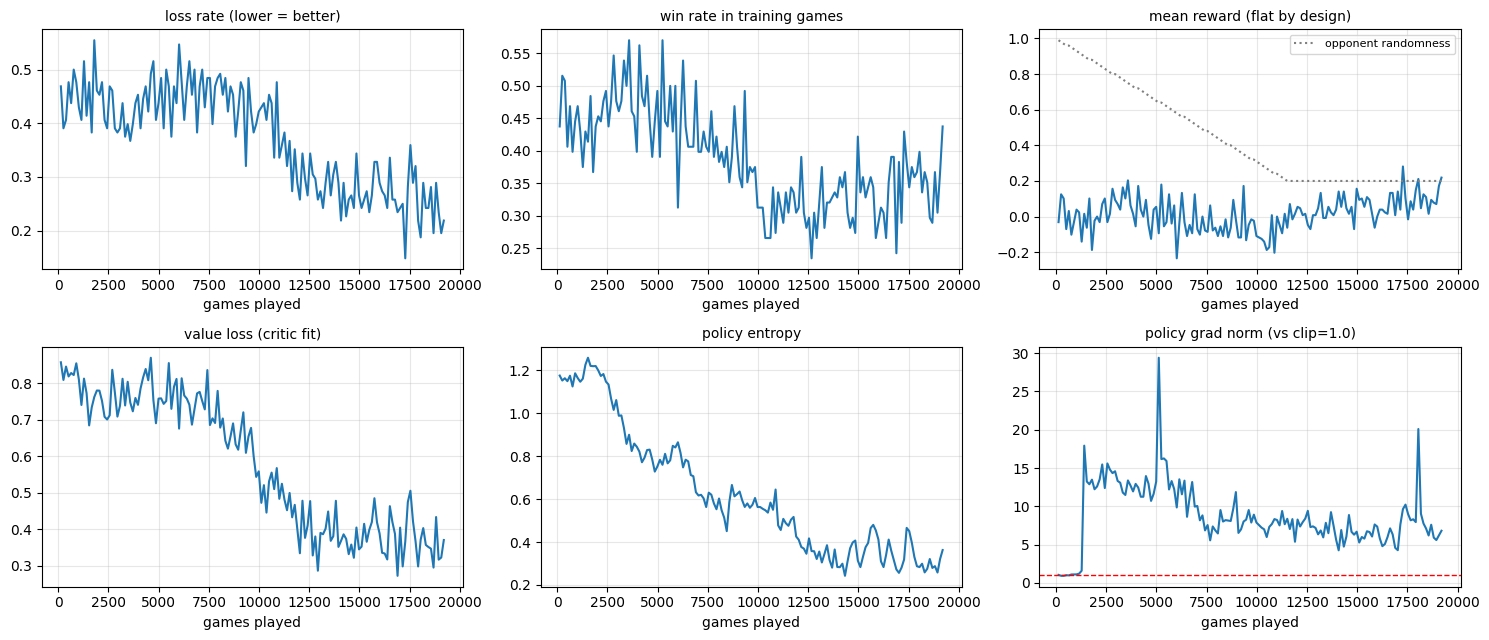

In [ ]:
import matplotlib.pyplot as plt

g = [h["games"] for h in history]
fig, ax = plt.subplots(2, 3, figsize=(15, 6.5))
for a, key, title in [
    (ax[0][0], "loss_rate", "loss rate (lower = better)"),
    (ax[0][1], "win", "win rate in training games"),
    (ax[0][2], "reward", "mean reward (flat by design)"),
    (ax[1][0], "vloss", "value loss (critic fit)"),
    (ax[1][1], "entropy", "policy entropy"),
    (ax[1][2], "gn_pol", "policy grad norm (vs clip=1.0)"),
]:
    a.plot(g, [h[key] for h in history])
    a.set_title(title, fontsize=10); a.set_xlabel("games played"); a.grid(alpha=.3)
ax[1][2].axhline(cfg.max_grad_norm, ls="--", c="r", lw=1)
ax[0][2].plot(g, [h["p_rand"] for h in history], ls=":", c="gray", label="opponent randomness")
ax[0][2].legend(fontsize=8)
plt.tight_layout()

---
# Part 5 — Saving the trained model

In [ ]:
save_checkpoint(policy, "checkpoints/01_ppo", stage="ppo",
                games_seen=cfg.iters * cfg.games_per_iter,
                train_minutes=round((time.time() - t0) / 60, 1))
print("saved -> checkpoints/01_ppo")
print(os.listdir("checkpoints/01_ppo"))

saved -> checkpoints/01_ppo
['manifest.json', 'model.pt']


---
# Part 6 — Testing the trained model

Exactly the same `full_evaluation` as Part 3.3: same `N_GAMES`, same opponents, same position sweep.
Nothing about the test changed, so the two columns are directly comparable.

In [ ]:
RESULTS["after"] = full_evaluation(policy, "AFTER PPO TRAINING")

===== AFTER PPO TRAINING =====
vs RANDOM opponent   (n=400): win 0.752  draw 0.150  loss 0.098
vs STRONG opponent   (n=400): win 0.265  draw 0.715  loss 0.020
all 4520 positions      : top-1 0.663 (chance 0.494)  blunder 0.195 (chance 0.340)  top-1 forced 0.550
(29s)


---
# Part 7 — Before vs after

## 7.1 The results table

The grey rows are **exact** reference points computed from the game tree, not measurements. They tell
you what the numbers mean: a random player wins 43.7% against a random opponent, a perfect player
wins 90.1% and **never loses**. Square brackets are 95% confidence intervals.

In [ ]:
from IPython.display import HTML, display


def comparison_table(results):
    rows = [dict(name="Random play (floor)", n=None, kind="ref",
                 win=REF_RANDOM[0], draw=REF_RANDOM[1], loss=REF_RANDOM[2])]
    for key, label in [("before", "BEFORE training"), ("after", "AFTER PPO")]:
        c = results[key]["vs_random"]
        rows.append(dict(name=label, n=c["n"], kind="meas", counts=c,
                         win=c["win"]/c["n"], draw=c["draw"]/c["n"], loss=c["loss"]/c["n"]))
    rows.append(dict(name="Perfect play (ceiling)", n=None, kind="ref",
                     win=REF_PERFECT[0], draw=REF_PERFECT[1], loss=REF_PERFECT[2]))

    def cell(r, key, bold=False):
        s = f"{r[key]:.3f}"
        if r["kind"] == "meas":
            lo, up = wilson(r["counts"][key], r["n"])
            s += f"<div style='font:10px system-ui;color:#999'>[{lo:.3f}, {up:.3f}]</div>"
        return (f"<td style='padding:8px 14px;text-align:right;"
                f"font:{'600' if bold else '400'} 13px ui-monospace,monospace'>{s}</td>")

    body = ""
    for r in rows:
        sh = "background:#fafafa;color:#777" if r["kind"] == "ref" else ""
        body += (f"<tr style='{sh};border-top:1px solid #eee'>"
                 f"<td style='padding:8px 14px;font:{'600' if r['kind']=='meas' else '400'} 13px system-ui'>"
                 f"{r['name']}</td>"
                 f"<td style='padding:8px 14px;text-align:right;font:11px system-ui;color:#999'>"
                 f"{r['n'] or 'exact'}</td>"
                 + cell(r, "win") + cell(r, "draw") + cell(r, "loss", bold=True) + "</tr>")
    head = "<tr>" + "".join(
        f"<th style='padding:8px 14px;text-align:{a};font:600 11px system-ui;"
        f"letter-spacing:.05em;text-transform:uppercase;color:#666'>{h}</th>"
        for h, a in [("agent", "left"), ("games", "right"), ("win", "right"),
                     ("draw", "right"), ("loss", "right")]) + "</tr>"

    b, a_ = results["before"], results["after"]
    zl, pl = two_prop_z(b["vs_random"]["loss"], b["vs_random"]["n"],
                        a_["vs_random"]["loss"], a_["vs_random"]["n"])
    zw, pw = two_prop_z(b["vs_random"]["win"], b["vs_random"]["n"],
                        a_["vs_random"]["win"], a_["vs_random"]["n"])
    pos = ("<table style='border-collapse:collapse;margin-top:18px;border:1px solid #e5e5e5'>"
           "<thead style='background:#f5f5f5'><tr>"
           + "".join(f"<th style='padding:8px 14px;font:600 11px system-ui;text-transform:uppercase;"
                     f"letter-spacing:.05em;color:#666'>{h}</th>"
                     for h in ["all 4,520 positions", "chance", "before", "after"])
           + "</tr></thead><tbody>")
    for key, lbl, chance, better_low in [("top1", "top-1 correct move", _chance_top1, False),
                                         ("top1_forced", "top-1 on forced positions", None, False),
                                         ("blunder", "blunder rate (lower better)", _chance_blunder, True)]:
        ch = f"{chance:.3f}" if chance is not None else "-"
        pos += (f"<tr style='border-top:1px solid #eee'>"
                f"<td style='padding:8px 14px;font:13px system-ui'>{lbl}</td>"
                f"<td style='padding:8px 14px;text-align:right;font:12px ui-monospace,monospace;color:#999'>{ch}</td>"
                f"<td style='padding:8px 14px;text-align:right;font:13px ui-monospace,monospace'>"
                f"{b['positions'][key]:.3f}</td>"
                f"<td style='padding:8px 14px;text-align:right;font:600 13px ui-monospace,monospace'>"
                f"{a_['positions'][key]:.3f}</td></tr>")
    pos += "</tbody></table>"

    note = (f"<div style='font:12px/1.7 system-ui;color:#555;margin-top:12px'>"
            f"Greedy play, agent is X in half the games. "
            f"<b>Loss rate:</b> {b['vs_random']['loss']/b['vs_random']['n']:.3f} &rarr; "
            f"{a_['vs_random']['loss']/a_['vs_random']['n']:.3f} "
            f"(z={zl:+.2f}, p={pl:.2e}). "
            f"<b>Win rate:</b> z={zw:+.2f}, p={pw:.2e}.</div>")

    return HTML(f"<h3 style='font:600 15px system-ui'>Game outcomes vs a random opponent</h3>"
                f"<table style='border-collapse:collapse;border:1px solid #e5e5e5'>"
                f"<thead style='background:#f5f5f5'>{head}</thead><tbody>{body}</tbody></table>"
                f"<h3 style='font:600 15px system-ui;margin-top:22px'>Move quality on every position "
                f"in the game</h3>{pos}{note}")


display(comparison_table(RESULTS))

## 7.2 Where the remaining mistakes are

Top-1 accuracy broken down by how many pieces are on the board. Early positions are strategic
(forks, centre control); late positions are forced. This shows which end the model still fails at.

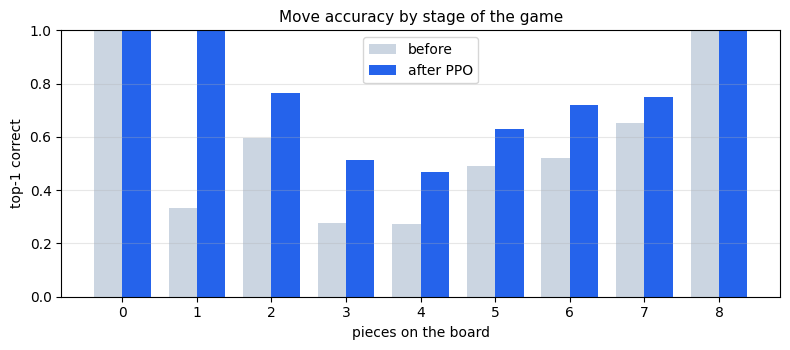

In [ ]:
plies = sorted(RESULTS["after"]["positions"]["per_ply"])
fig, ax = plt.subplots(figsize=(8, 3.6))
w = 0.38
ax.bar([p - w/2 for p in plies], [RESULTS["before"]["positions"]["per_ply"][p] for p in plies],
       w, label="before", color="#cbd5e1")
ax.bar([p + w/2 for p in plies], [RESULTS["after"]["positions"]["per_ply"][p] for p in plies],
       w, label="after PPO", color="#2563eb")
ax.set_xlabel("pieces on the board"); ax.set_ylabel("top-1 correct")
ax.set_xticks(plies); ax.set_ylim(0, 1); ax.legend(); ax.grid(axis="y", alpha=.3)
ax.set_title("Move accuracy by stage of the game", fontsize=11)
plt.tight_layout()

## 7.3 Written verdict

Auto-generated from the measured numbers, so it cannot drift from the results above.

In [ ]:
b, a_ = RESULTS["before"], RESULTS["after"]
bl, al = b["vs_random"]["loss"] / b["vs_random"]["n"], a_["vs_random"]["loss"] / a_["vs_random"]["n"]
bw, aw = b["vs_random"]["win"] / b["vs_random"]["n"], a_["vs_random"]["win"] / a_["vs_random"]["n"]
zl, pl = two_prop_z(b["vs_random"]["loss"], b["vs_random"]["n"],
                    a_["vs_random"]["loss"], a_["vs_random"]["n"])
gap_loss = (bl - al) / bl if bl > 0 else float("nan")
gap_win = (aw - bw) / (REF_PERFECT[0] - bw) if REF_PERFECT[0] > bw else float("nan")

print(f"""CONCLUSION
==========
Setup      : {cfg.model_name}, {cfg.iters} PPO iterations, {cfg.iters*cfg.games_per_iter} games played,
             reward = game outcome only (no move labels were ever shown to the model).

Game play  : loss rate vs a random opponent {bl:.3f} -> {al:.3f}
             ({gap_loss:.0%} of the gap to zero closed; z={zl:+.2f}, p={pl:.2e}, n={N_GAMES} each)
             win rate {bw:.3f} -> {aw:.3f}, against a random floor of {REF_RANDOM[0]:.3f}
             and a perfect ceiling of {REF_PERFECT[0]:.3f} ({gap_win:.0%} of that gap closed)

Move quality (all {b['positions']['n']} positions, zero sampling noise):
             top-1 correct   {b['positions']['top1']:.3f} -> {a_['positions']['top1']:.3f}   (chance {_chance_top1:.3f})
             forced positions {b['positions']['top1_forced']:.3f} -> {a_['positions']['top1_forced']:.3f}
             blunder rate    {b['positions']['blunder']:.3f} -> {a_['positions']['blunder']:.3f}   (chance {_chance_blunder:.3f}, lower better)

Read it as : the model {'DID learn' if al < bl and a_['positions']['top1'] > b['positions']['top1'] else 'did NOT clearly learn'} to play.
             Any remaining loss against a *random* opponent means positions where it still
             fails to block a threat or to take a win that was on the board.""")

CONCLUSION
Setup      : gpt2, 150 PPO iterations, 19200 games played,
             reward = game outcome only (no move labels were ever shown to the model).

Game play  : loss rate vs a random opponent 0.357 -> 0.098
             (73% of the gap to zero closed; z=+8.77, p=1.77e-18, n=400 each)
             win rate 0.610 -> 0.752, against a random floor of 0.437
             and a perfect ceiling of 0.901 (49% of that gap closed)

Move quality (all 4520 positions, zero sampling noise):
             top-1 correct   0.503 -> 0.663   (chance 0.494)
             forced positions 0.362 -> 0.550
             blunder rate    0.338 -> 0.195   (chance 0.340, lower better)

Read it as : the model DID learn to play.
             Any remaining loss against a *random* opponent means positions where it still
             fails to block a threat or to take a win that was on the board.


---
# Part 8 — Play against the model

## 8.1 Pick an opponent and play


In [ ]:
# ============================================================
#  Play against your trained model — Gradio UI, right in Colab
# ============================================================
%pip install -q gradio

import random, gradio as gr, torch, numpy as np

# ---------- move-selection helpers (reuses the notebook's Policy, encode, etc.) ----------
@torch.no_grad()
def _policy_probs(policy, board, mark):
    was = policy.training
    policy.eval()
    ids, attn, pos = encode([build_prompt(board, mark)])
    legal = torch.from_numpy(legal_mask(board)[None]).to(DEVICE)
    logits, value = policy(ids, attn, pos, legal)
    p = logits.softmax(-1)[0].float().cpu().numpy()
    if was: policy.train()
    return p, float(value)


def _opponent_move(board, mark, kind, model=None):
    if kind == "Random":
        return random.choice(legal_moves(board))
    if kind == "Perfect (minimax)":
        if random.random() < 0.15:              # small noise so games aren't identical
            return random.choice(legal_moves(board))
        return _minimax(board, mark)[1]
    if kind == "Trained model":                  # the model you just trained
        p, _ = _policy_probs(model, board, mark)
        return int(p.argmax())
    if kind == "Untrained model":                # requires `base` from Part 8
        p, _ = _policy_probs(base, board, mark)
        return int(p.argmax())
    raise ValueError(kind)


def _render_board_svg(board, probs=None, last_move=None, hint_cells=(), size=280):
    cell = size // 3
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{size}" height="{size}" '
             f'viewBox="0 0 {size} {size}" style="background:#F7F9FC;border-radius:10px;">']
    for k in (1, 2):
        parts.append(f'<line x1="{k*cell}" y1="10" x2="{k*cell}" y2="{size-10}" '
                     f'stroke="#94A3B8" stroke-width="2.5" stroke-linecap="round"/>')
        parts.append(f'<line x1="10" y1="{k*cell}" x2="{size-10}" y2="{k*cell}" '
                     f'stroke="#94A3B8" stroke-width="2.5" stroke-linecap="round"/>')
    for i, v in enumerate(board):
        r, c = i // 3, i % 3
        cx, cy = c * cell + cell // 2, r * cell + cell // 2
        if v == X:
            parts.append(f'<text x="{cx}" y="{cy+int(cell*0.15)}" font-family="Georgia" '
                         f'font-size="{int(cell*0.55)}" font-weight="700" fill="#2563EB" '
                         f'text-anchor="middle">X</text>')
        elif v == O:
            parts.append(f'<text x="{cx}" y="{cy+int(cell*0.15)}" font-family="Georgia" '
                         f'font-size="{int(cell*0.55)}" font-weight="700" fill="#DC2626" '
                         f'text-anchor="middle">O</text>')
        else:
            parts.append(f'<text x="{cx}" y="{cy-int(cell*0.22)}" font-family="ui-monospace,monospace" '
                         f'font-size="{int(cell*0.16)}" fill="#94A3B8" text-anchor="middle">{i}</text>')
            if probs is not None and probs[i] > 0.001:
                op = min(0.8, 0.15 + probs[i] * 1.2)
                parts.append(f'<circle cx="{cx}" cy="{cy+int(cell*0.05)}" r="{int(cell*0.25)}" '
                             f'fill="#2BB3AC" fill-opacity="{op:.3f}"/>')
                parts.append(f'<text x="{cx}" y="{cy+int(cell*0.12)}" font-family="ui-monospace,monospace" '
                             f'font-size="{int(cell*0.16)}" fill="#0F766E" font-weight="700" '
                             f'text-anchor="middle">{probs[i]:.2f}</text>')
            if i in hint_cells:
                parts.append(f'<circle cx="{cx}" cy="{cy}" r="{int(cell*0.06)}" fill="#F2B134"/>')
        if last_move == i:
            parts.append(f'<rect x="{c*cell+4}" y="{r*cell+4}" width="{cell-8}" height="{cell-8}" '
                         f'fill="none" stroke="#F2B134" stroke-width="2.5" stroke-dasharray="5 3" rx="4"/>')
    parts.append('</svg>')
    return ''.join(parts)


# ---------- state = a plain dict, held in gr.State ----------
def _fresh(human_mark, opp_kind, show_probs, show_hint, model_for_opp):
    st = {"board": tuple([EMPTY] * 9), "to_move": X, "human_mark": human_mark,
          "moves": [], "over": False, "result": None, "last": None,
          "opp": opp_kind, "show_probs": show_probs, "show_hint": show_hint}
    # if human plays second, let the opponent open
    if human_mark == O and opp_kind != "You (both sides)":
        om = _opponent_move(st["board"], X, opp_kind, model=model_for_opp)
        st["board"] = place(st["board"], om, X)
        st["moves"].append(("opp", om, X)); st["to_move"] = O; st["last"] = om
    return st


def _finish(st):
    w = winner(st["board"])
    st["over"] = True
    st["result"] = "draw" if w == EMPTY else ("human" if w == st["human_mark"] else "opp")
    return st


def _status_line(st):
    if st["over"]:
        return {"human": "🎉 You win!", "opp": "You lose.", "draw": "Draw."}[st["result"]]
    if st["to_move"] == st["human_mark"]:
        return f"Your turn — you are {SYM[st['human_mark']]}."
    return "Opponent is thinking…"


def _view(st):
    """Compute the board SVG, status text, and info panel for the current state."""
    # what should the trained model do here? (only shown when it's the human's turn)
    probs_display = None
    info_lines = []
    hint = ()
    if not st["over"] and st["to_move"] == st["human_mark"]:
        if st["show_probs"]:
            probs, val = _policy_probs(policy, st["board"], st["human_mark"])
            probs_display = probs
            info_lines.append(f"**Trained model's view of this position**  \n"
                              f"value head estimate: `{val:+.2f}`  \n"
                              f"top cells: " + ", ".join(
                                  f"`{c}:{probs[c]:.2f}`" for c in np.argsort(-probs)[:3]))
        if st["show_hint"]:
            opt = optimal_moves(st["board"], st["human_mark"])
            hint = tuple(opt)
            verdict = ("already lost" if position_is_lost(st["board"], st["human_mark"])
                       else "you can still draw/win")
            info_lines.append(f"**Solver hint** — best cell(s): `{opt}` ({verdict})")
    if st["over"]:
        info_lines.append("Move log: " + " ".join(
            f"{'you' if who=='human' else 'opp'}:{cell}" for who, cell, _ in st["moves"]))
    svg = _render_board_svg(st["board"], probs=probs_display, last_move=st["last"], hint_cells=hint)
    return svg, _status_line(st), "\n\n".join(info_lines) if info_lines else " "


def _click(cell, st, opp_kind, human_mark_lbl, show_probs, show_hint):
    st["opp"] = opp_kind
    st["show_probs"] = show_probs
    st["show_hint"] = show_hint
    if st["over"]:
        svg, status, info = _view(st)
        return st, svg, status, info + "\n\n_Click **New game** to play again._"
    if cell not in legal_moves(st["board"]):
        svg, status, info = _view(st)
        return st, svg, status, "That cell is taken."
    if st["to_move"] != st["human_mark"]:
        svg, status, info = _view(st)
        return st, svg, status, info

    st["board"] = place(st["board"], cell, st["human_mark"])
    st["moves"].append(("human", cell, st["human_mark"]))
    st["last"] = cell
    st["to_move"] = other(st["human_mark"])
    if is_terminal(st["board"]):
        st = _finish(st); svg, status, info = _view(st)
        return st, svg, status, info

    if opp_kind != "You (both sides)":
        om = _opponent_move(st["board"], st["to_move"], opp_kind, model=policy)
        st["board"] = place(st["board"], om, st["to_move"])
        st["moves"].append(("opp", om, st["to_move"]))
        st["last"] = om
        st["to_move"] = other(st["to_move"])
        if is_terminal(st["board"]):
            st = _finish(st)

    svg, status, info = _view(st)
    return st, svg, status, info


def _new(human_mark_lbl, opp_kind, show_probs, show_hint):
    hm = X if human_mark_lbl.startswith("X") else O
    st = _fresh(hm, opp_kind, show_probs, show_hint, model_for_opp=policy)
    svg, status, info = _view(st)
    return st, svg, status, info


# ---------- UI ----------
with gr.Blocks(title="Play GPT-2 tic-tac-toe", theme=gr.themes.Soft()) as demo:
    gr.Markdown("## Play against your trained model\n"
                "Pick an opponent, choose whether you play X or O, then click a cell to move.")
    state = gr.State(_fresh(X, "Trained model", True, True, model_for_opp=policy))

    with gr.Row():
        with gr.Column(scale=1):
            opp = gr.Radio(["Trained model", "Untrained model", "Perfect (minimax)", "Random", "You (both sides)"],
                           value="Trained model", label="Opponent")
            mark = gr.Radio(["X (you go first)", "O (opponent goes first)"], value="X (you go first)",
                            label="Your mark")
            show_probs = gr.Checkbox(True, label="Show trained model's probability for each cell")
            show_hint = gr.Checkbox(True, label="Show solver hint (best cell for you)")
            new_btn = gr.Button("New game", variant="primary")

        with gr.Column(scale=1):
            board_html = gr.HTML(_render_board_svg((EMPTY,) * 9))
            status = gr.Markdown("Your turn — you are X.")
            info = gr.Markdown(" ")

            with gr.Row():
                cell_buttons = [gr.Button(str(i), scale=1, min_width=40) for i in range(9)]
            gr.Markdown("*Cell numbers: `0 1 2 / 3 4 5 / 6 7 8`. Buttons above map to that grid.*",
                        elem_classes=[])

    outputs = [state, board_html, status, info]
    for i, btn in enumerate(cell_buttons):
        btn.click(fn=_click, inputs=[gr.State(i), state, opp, mark, show_probs, show_hint],
                  outputs=outputs)
    new_btn.click(fn=_new, inputs=[mark, opp, show_probs, show_hint], outputs=outputs)

    # initial render matches initial state
    demo.load(fn=lambda st: _view(st), inputs=[state], outputs=[board_html, status, info])

demo.launch(share=True, debug=False)

/tmp/ipykernel_1704/4077939723.py:174: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(title="Play GPT-2 tic-tac-toe", theme=gr.themes.Soft()) as demo:


NameError: name 'X' is not defined